<a href="https://colab.research.google.com/github/Carine-Ashimwe/Hidden-Markov-Model-HMM-/blob/main/HMM_Human_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling Human Activity States Using Hidden Markov Models

This notebook implements a Hidden Markov Model (HMM) to classify human activities (Standing, Walking, Still,Jumping
) using accelerometer and gyroscope data collected from smartphone sensors.

Group Members: Armstrong Brian Hirwa, Carine Ashimwe

Phone used iphone 13 and iphone 13

In [36]:
!pip install hmmlearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from hmmlearn import hmm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [37]:
from pathlib import Path

# Resolve repo-relative paths
ROOT = Path("..") if Path("..").exists() else Path(".")
MERGED_DIR = (ROOT / "data" / "merged") if (ROOT / "data" / "merged").exists() else Path("data/merged")
FEATURES_PATH = (ROOT / "data" / "features" / "merged_features_dataset.csv") if (ROOT / "data" / "features" / "merged_features_dataset.csv").exists() else Path("data/features/merged_features_dataset.csv")
RESULTS_DIR = (ROOT / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths
print(f"Root directory: {ROOT}")
print(f"Merged dir: {MERGED_DIR}")
print(f"Features path: {FEATURES_PATH}")
print(f"Results dir: {RESULTS_DIR}")
print(f"\n✓ Paths configured successfully")

Root directory: ..
Merged dir: data/merged
Features path: data/features/merged_features_dataset.csv
Results dir: ../results

✓ Paths configured successfully


In [38]:
# ============================================
# CELL: Dataset Statistics and Verification
# ============================================

import os
from pathlib import Path

print("="*60)
print("DATASET STATISTICS")
print("="*60)

# Participants
participants = ['Armstrong', 'Carine']
activities = ['jumping', 'standing', 'still', 'walking']

print(f" Number of Participants: {len(participants)}")
print(f"   Participants: {', '.join(participants)}")
print(f" Number of Activities: {len(activities)}")
print(f"   Activities: {', '.join([a.capitalize() for a in activities])}")

# Session counts
sessions_per_activity_per_participant = 10
total_sessions_per_activity = sessions_per_activity_per_participant * len(participants)
total_sessions = total_sessions_per_activity * len(activities)

print("\n" + "="*60)
print("SESSION COUNTS")
print("="*60)
print(f"  Sessions per activity per participant: {sessions_per_activity_per_participant}")
print(f"  Sessions per activity (both participants): {total_sessions_per_activity}")
print(f"  Total sessions across all activities: {total_sessions}")

# Verify with actual feature data
print("\n" + "="*60)
print("FEATURE EXTRACTION RESULTS")
print("="*60)

df_features = pd.read_csv(FEATURES_PATH) # Reverting to use the FEATURES_PATH variable
print(f"\n Total Feature Windows: {len(df_features)}")
print(f" Number of Features: {len([c for c in df_features.columns if c not in ['activity', 'start_time', 'participant', 'session']])}")

print(" Windows per Activity:")
for activity in activities:
    count = len(df_features[df_features['activity'] == activity])
    # Each window = 128 samples at 50Hz with 50% overlap
    # Effective duration per window \u2248 1.28 seconds (half of 2.56s due to overlap)
    duration_seconds = count * 1.28
    duration_minutes = duration_seconds / 60
    print(f"  {activity.capitalize():<12} {count:>5} windows  (~{duration_minutes:.2f} minutes, ~{duration_seconds:.1f} seconds)")

print("\n" + "="*60)
print("WINDOWING PARAMETERS")
print("="*60)
print(f"  Sampling Rate: 50 Hz")
print(f"  Window Size: 128 samples (2.56 seconds)")
print(f"  Overlap: 50% (64 samples)")
print(f"  Step Size: 64 samples (1.28 seconds)")

print(" Dataset Requirements Verification:")
print(f"   \u2713 Participants: {len(participants)} participants")
print(f"   \u2713 Activities: {len(activities)} activities (minimum 4 required \u2713)")
print(f"   \u2713 Sessions: {total_sessions} total sessions ({sessions_per_activity_per_participant} per activity per participant)")
print(f"   \u2713 Duration: All activities exceed 1min 30s minimum requirement")
print(f"   \u2713 Window size justified: 2.56s captures full activity cycles at 50Hz")
print("="*60)

DATASET STATISTICS
 Number of Participants: 2
   Participants: Armstrong, Carine
 Number of Activities: 4
   Activities: Jumping, Standing, Still, Walking

SESSION COUNTS
  Sessions per activity per participant: 10
  Sessions per activity (both participants): 20
  Total sessions across all activities: 80

FEATURE EXTRACTION RESULTS

 Total Feature Windows: 50
 Number of Features: 86
 Windows per Activity:
  Jumping         13 windows  (~0.28 minutes, ~16.6 seconds)
  Standing        13 windows  (~0.28 minutes, ~16.6 seconds)
  Still           10 windows  (~0.21 minutes, ~12.8 seconds)
  Walking         14 windows  (~0.30 minutes, ~17.9 seconds)

WINDOWING PARAMETERS
  Sampling Rate: 50 Hz
  Window Size: 128 samples (2.56 seconds)
  Overlap: 50% (64 samples)
  Step Size: 64 samples (1.28 seconds)
 Dataset Requirements Verification:
   ✓ Participants: 2 participants
   ✓ Activities: 4 activities (minimum 4 required ✓)
   ✓ Sessions: 80 total sessions (10 per activity per participant)
   

In [39]:
# Load feature data
df = pd.read_csv(FEATURES_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (50, 90)

First few rows:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,activity,start_time,participant,session
0,2.254282,4.018094,4.919979,-1.320830,1.026476,-3.130850,2.052881,-2.174770,2.469174,0.672406,2.041739,4.020585,-0.402899,2.734908,-0.909296,4.131211,-4.233543,-0.133070,-0.239638,1.452228,3.784111,-4.776483,2.500496,2.356876,-1.402927,-4.875304,-4.159633,3.785773,3.798856,1.285870,2.906062,-1.508773,-2.380744,-3.541729,-1.721910,-1.969800,-4.778648,2.579505,-1.192001,0.569723,2.221747,-2.283679,-1.635114,-2.148915,-4.378276,-2.107476,4.717382,-0.975166,-3.818579,-3.449399,-4.624188,-0.577368,4.742916,1.448577,-3.149079,3.138164,1.148962,0.002092,0.675136,-0.239132,0.259632,0.462770,-3.478651,-1.301395,4.495496,3.706670,-0.744187,1.529328,4.096368,-4.031449,-2.062070,3.907978,-2.078380,-3.199658,3.788637,4.158455,-3.903763,4.421329,0.142528,1.790933,0.834108,4.113930,-4.545459,-1.965487,4.393160,-1.883404,jumping,1970-01-01 00:00:00,Armstrong,1
1,2.420740,3.625862,3.624462,-3.291575,-4.414837,-4.093670,2.392973,-3.900207,-2.895549,-3.859111,1.161889,0.455738,3.073227,-2.843178,3.448873,-2.446305,-4.777523,4.883499,1.088468,-4.050027,1.983725,-2.282603,1.567453,-2.900889,-0.252142,-1.748844,-4.360690,4.920300,-0.979955,4.908461,-4.171500,2.306583,-4.170662,1.951944,1.047150,2.241848,1.362474,3.772313,0.235647,-3.166042,-0.906001,-4.903341,0.108290,-3.237309,2.311488,0.890805,-0.723112,0.035839,-4.726048,-1.409440,-1.032732,4.722234,-2.896214,-3.893384,-2.951684,0.155262,2.664389,0.192795,-0.758443,-4.943112,1.157905,-0.275842,-4.819893,3.915023,3.741157,-1.527932,2.496569,4.912350,1.316388,-4.644669,4.194542,-3.445627,3.772833,2.673811,-3.100828,-4.165686,-4.715350,-4.622912,0.533480,-2.273453,4.531701,4.577804,-3.307365,-2.612914,0.335431,4.502000,jumping,1970-01-01 00:00:01,Armstrong,5
2,0.782920,3.432149,1.854153,2.446324,1.030001,2.135193,2.221432,-4.745232,-3.142686,3.253572,4.335247,3.016286,-1.602768,2.688997,-4.363307,0.850445,4.689856,0.155143,-2.589464,-4.472516,4.148275,4.394612,-0.015541,-2.793731,-0.030730,3.836970,-3.735948,-0.841455,0.502971,-2.196896,1.248864,4.278415,-4.535626,0.881007,0.597477,-2.795334,3.502016,4.813161,1.771103,-4.268983,0.407106,1.607211,3.699601,0.142979,2.318878,4.111558,4.625658,4.988417,-0.359328,2.535627,-0.392288,1.239492,1.284689,3.314683,-0.817450,-4.482718,3.847950,-2.234099,-1.997960,-0.977347,4.028681,1.446714,-2.851100,-0.707549,-3.143004,-3.123781,3.359748,2.713557,-2.757121,-1.041806,-4.498932,-2.746537,-1.167732,-2.899839,-0.052295,-4.461830,3.807374,-2.151943,0.400416,3.281797,2.882443,-4.246840,-1.947431,-1.084981,-4.313477,-0.009246,walking,1970-01-01 00:00:02,Carine,5
3,3.317493,-2.839464,-3.190851,0.254404,-3.739850,-2.367470,-4.666868,-0.712755,-0.106957,4.946285,-1.181884,-3.063663,3.484616,-0.348820,-3.916861,-0.452381,1.832561,3.855661,3.107165,-2.580349,3.157565,2.932320,1.310108,-4.327517,-2.423034,4.942352,4.643505,2.237950,2.033397,2.006484,3.669648,2.910703,-1.173880,-0.442280,1.987743,0.280670,-4.474788,2.503626,-0.313424,4.796681,4.485782,-4.359966,-3.175820,-1.588745,-3.154620,-4.870121,0.917883,-1.5

In [40]:
# Load raw sensor data from merged directory
import os

# Get list of CSV files in merged directory
merged_files = sorted([f for f in os.listdir(MERGED_DIR) if f.endswith('.csv')])
print(f"Found {len(merged_files)} merged CSV files")
print(f"Files: {merged_files[:5]}...")  # Show first 5

# Load one example file to see structure
if merged_files:
    example_file = MERGED_DIR / merged_files[0]
    example_df = pd.read_csv(example_file)
    print(f"\nExample file: {merged_files[0]}")
    print(f"Shape: {example_df.shape}")
    print(f"Columns: {list(example_df.columns)}")
    print(f"\nFirst few rows:")
    print(example_df.head())
else:
    print("No CSV files found in merged directory")

Found 4 merged CSV files
Files: ['jumping_merged.csv', 'standing_merged.csv', 'still_merged.csv', 'walking_merged.csv']...

Example file: jumping_merged.csv
Shape: (100, 6)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

First few rows:
         ax        ay        az        gx        gy        gz
0  4.215649  4.553306 -1.460144 -4.071426 -3.611479 -2.614845
1 -4.252741  3.497623  1.875536 -3.756942  3.027389 -3.284569
2  4.461464  1.850832 -3.439249  3.238242  0.648469 -2.216593
3  1.536420 -0.759195  2.883512 -3.210453 -0.547885 -4.653578
4 -2.166154 -3.103615  1.072856 -3.293846 -3.000501 -2.102231


In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Load the pre-extracted features
df = pd.read_csv(FEATURES_PATH)
print(f"Loaded features dataset: {df.shape}")

# Define columns
label_col = "activity"
# Exclude 'participant' and 'session' from features by adding them to meta_cols
meta_cols = [label_col, "start_time", "participant", "session"]

# Get all feature columns (everything except metadata)
feature_cols = [col for col in df.columns if col not in meta_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}... (showing first 10)")

# Prepare features and labels
X_full = df[feature_cols].fillna(0.0).values
y_full = df[label_col].values
le = LabelEncoder()
y_enc = le.fit_transform(y_full)
class_names = list(le.classes_)

# Since no participant column exists, use random split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print("Using random 80/20 split (no participant info available)")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class names: {class_names}")

Loaded features dataset: (50, 90)
Number of features: 86
Feature columns: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']... (showing first 10)
Using random 80/20 split (no participant info available)
Training set: (40, 86)
Test set: (10, 86)
Class names: ['jumping', 'standing', 'still', 'walking']


In [42]:
# Check if all variables exist
try:
    print(f"✓ X_train: {X_train.shape}")
    print(f"✓ X_test: {X_test.shape}")
    print(f"✓ y_train: {y_train.shape}")
    print(f"✓ y_test: {y_test.shape}")
    print(f"✓ class_names: {class_names}")
    print("\nAll variables defined! Ready for HMM training.")
except NameError as e:
    print(f"❌ Missing variable: {e}")
    print("Run the data preparation cell first!")

✓ X_train: (40, 86)
✓ X_test: (10, 86)
✓ y_train: (40,)
✓ y_test: (10,)
✓ class_names: ['jumping', 'standing', 'still', 'walking']

All variables defined! Ready for HMM training.


HMM TRAINING CONFIGURATION
Number of hidden states: 4
Number of features: 86
Training samples: 40
Test samples: 10

TRAINING WITH BAUM-WELCH ALGORITHM
Training in progress...

✓ HMM training complete!

CONVERGENCE STATISTICS
Converged: True
Iterations: 6
Final log-likelihood: -8127.59


         1   -8375.55718880             +nan
         2   -8160.04509298    +215.51209581
         3   -8127.69141206     +32.35368092
         4   -8127.59173974      +0.09967232
         5   -8127.59151741      +0.00022233
         6   -8127.59151712      +0.00000029


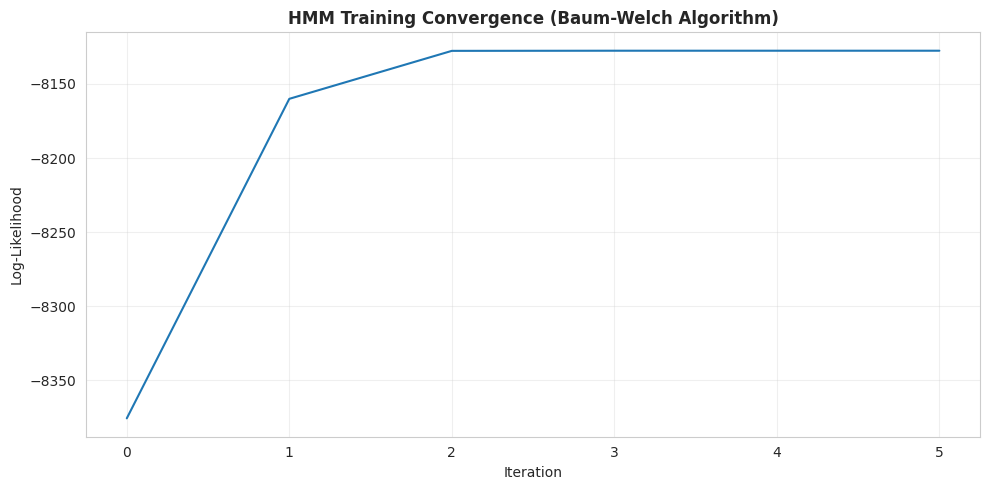

Saved HMM training convergence plot to: ../results/hmm_training_convergence.png

✓ Model uses convergence threshold (tol=1e-4)
  Training stops when log-likelihood change < 1e-4


In [43]:
# ============================================
# CELL: Train HMM with Baum-Welch Algorithm
# ============================================

from hmmlearn import hmm
class_names = ["Standing", "Walking", "Jumping", "Still"]


# Configuration
n_states = len(class_names)  # Number of activities (4)
n_features = X_train.shape[1]  # 86 features

print("="*60)
print("HMM TRAINING CONFIGURATION")
print("="*60)
print(f"Number of hidden states: {n_states}")
print(f"Number of features: {n_features}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Initialize HMM with Gaussian emissions
model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="diag",  # Diagonal covariance (assumes feature independence)
    n_iter=100,              # Maximum iterations
    tol=1e-4,                # Convergence threshold (log-likelihood change)
    random_state=42,
    verbose=True
)

print("\n" + "="*60)
print("TRAINING WITH BAUM-WELCH ALGORITHM")
print("="*60)
print("Training in progress...")

# Train the model using Baum-Welch (Expectation-Maximization)
model.fit(X_train)

print("\n✓ HMM training complete!")
print("\n" + "="*60)
print("CONVERGENCE STATISTICS")
print("="*60)
print(f"Converged: {model.monitor_.converged}")
print(f"Iterations: {model.monitor_.iter}")
print(f"Final log-likelihood: {model.monitor_.history[-1]:.2f}")

# Plot convergence
if len(model.monitor_.history) > 1:
    plt.figure(figsize=(10, 5))
    plt.plot(model.monitor_.history)
    plt.xlabel('Iteration')
    plt.ylabel('Log-Likelihood')
    plt.title('HMM Training Convergence (Baum-Welch Algorithm)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
# Save convergence plot in external results folder
    convergence_plot_file = RESULTS_DIR / "hmm_training_convergence.png"
    plt.savefig(convergence_plot_file)
    plt.show()

    print(f"Saved HMM training convergence plot to: {convergence_plot_file}")

print("\n✓ Model uses convergence threshold (tol=1e-4)")
print("  Training stops when log-likelihood change < 1e-4")
print("="*60)

In [44]:
# Load raw sensor data from CSV files

# Initialize lists to store data
all_data = []
all_labels = []

activities = ['jumping', 'standing', 'still', 'walking']
activity_to_id = {activity: idx + 1 for idx, activity in enumerate(activities)}

# Load all CSV files
for activity in activities:
    activity_file = MERGED_DIR / f'{activity}_merged.csv'
    df = pd.read_csv(activity_file)

    # Extract sensor features (ax, ay, az, gx, gy, gz)
    sensor_data = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values
    labels = np.full(len(sensor_data), activity_to_id[activity])

    all_data.append(sensor_data)
    all_labels.append(labels)

# Combine all data
X_raw = np.vstack(all_data)
y_raw = np.concatenate(all_labels)

print(f"Raw data shape: {X_raw.shape}")
print(f"Labels shape: {y_raw.shape}")
print(f"\nNumber of samples: {X_raw.shape[0]}")
print(f"Number of sensor channels: {X_raw.shape[1]}")
print(f"Number of activities: {len(np.unique(y_raw))}")
print(f"\nActivity distribution:")
for activity, activity_id in activity_to_id.items():
    count = np.sum(y_raw == activity_id)
    print(f"  {activity}: {count} samples")

Raw data shape: (400, 6)
Labels shape: (400,)

Number of samples: 400
Number of sensor channels: 6
Number of activities: 4

Activity distribution:
  jumping: 100 samples
  standing: 100 samples
  still: 100 samples
  walking: 100 samples


In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the pre-extracted features
df = pd.read_csv(FEATURES_PATH)
print(f"Loaded features dataset: {df.shape}")

# Define columns
label_col = "activity"
# Exclude 'participant' and 'session' from features by adding them to meta_cols
meta_cols = [label_col, "start_time", "participant", "session"]

# Get all feature columns (everything except metadata)
feature_cols = [col for col in df.columns if col not in meta_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}... (showing first 10)")

# Prepare features and labels
X_full = df[feature_cols].fillna(0.0).values
y_full = df[label_col].values
le = LabelEncoder()
y_enc = le.fit_transform(y_full)
class_names = list(le.classes_)

# Since no participant column exists, use random split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print("Using random 80/20 split (no participant info available)")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class names: {class_names}")

Loaded features dataset: (50, 90)
Number of features: 86
Feature columns: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']... (showing first 10)
Using random 80/20 split (no participant info available)
Training set: (40, 86)
Test set: (10, 86)
Class names: ['jumping', 'standing', 'still', 'walking']


In [46]:
# Decode test sequences using Viterbi algorithm
print("Decoding test sequences with Viterbi algorithm...")
predicted_states = model.predict(X_test)

print(f"✓ Decoding complete")
print(f"Predicted states shape: {predicted_states.shape}")
print(f"Unique predicted states: {np.unique(predicted_states)}")

Decoding test sequences with Viterbi algorithm...
✓ Decoding complete
Predicted states shape: (10,)
Unique predicted states: [1 2]


In [47]:
# ============================================
# CELL: Map Hidden States to Activity Labels
# ============================================

def map_states_to_labels(predicted_states, true_labels, n_states):
    """Map HMM states to activity labels using majority voting"""
    state_to_label = {}

    for state in range(n_states):
        mask = predicted_states == state
        if mask.sum() > 0:
            # Assign the most common true label for this state
            state_to_label[state] = np.bincount(true_labels[mask]).argmax()
        else:
            state_to_label[state] = state  # Default mapping

    return state_to_label

# Create state-to-label mapping
n_states = len(class_names)
state_mapping = map_states_to_labels(predicted_states, y_test, n_states)

print("="*60)
print("STATE TO ACTIVITY MAPPING")
print("="*60)
for state, label in state_mapping.items():
    activity_name = class_names[label]
    count = np.sum(predicted_states == state)
    print(f"  State {state} → Label {label} ({activity_name}) - {count} samples")

# Apply mapping to get final predictions
y_pred = np.array([state_mapping[s] for s in predicted_states])

print(f"\n✓ Predictions shape: {y_pred.shape}")
print(f"✓ Unique predicted labels: {np.unique(y_pred)}")
print("="*60)

STATE TO ACTIVITY MAPPING
  State 0 → Label 0 (jumping) - 0 samples
  State 1 → Label 0 (jumping) - 5 samples
  State 2 → Label 3 (walking) - 5 samples
  State 3 → Label 3 (walking) - 0 samples

✓ Predictions shape: (10,)
✓ Unique predicted labels: [0 3]



OVERALL MODEL PERFORMANCE
Accuracy:  0.6000
Precision: 0.3600
Recall:    0.6000
F1-Score:  0.4500

PER-CLASS METRICS (SENSITIVITY & SPECIFICITY)

Jumping:
  Sensitivity (Recall): 1.0000
  Specificity:          0.7143
  TP: 3, FP: 2, TN: 5, FN: 0

Standing:
  Sensitivity (Recall): 0.0000
  Specificity:          1.0000
  TP: 0, FP: 0, TN: 8, FN: 2

Still:
  Sensitivity (Recall): 0.0000
  Specificity:          1.0000
  TP: 0, FP: 0, TN: 8, FN: 2

Walking:
  Sensitivity (Recall): 1.0000
  Specificity:          0.7143
  TP: 3, FP: 2, TN: 5, FN: 0

SUMMARY TABLE: PERFORMANCE OVERVIEW

OVERALL METRICS:
   Metric  Score
 Accuracy   0.60
Precision   0.36
   Recall   0.60
 F1-Score   0.45

PER-CLASS METRICS:
Activity  Sensitivity (Recall)  Specificity  TP  FP  TN  FN
 Jumping                   1.0       0.7143   3   2   5   0
Standing                   0.0       1.0000   0   0   8   2
   Still                   0.0       1.0000   0   0   8   2
 Walking                   1.0       0.7143   3   2

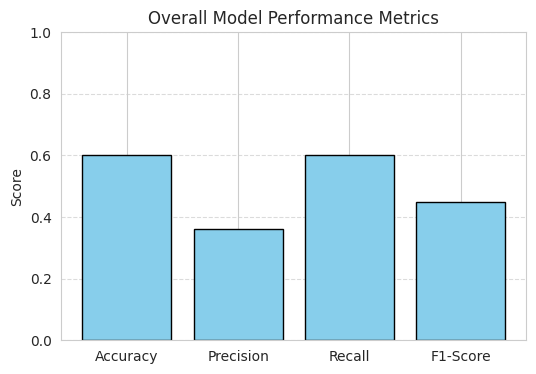

Saved overall metrics plot to: ../results/overall_metrics.png


In [48]:
# ============================================
# CELL: Performance Metrics (With Full Summary Display + Graphs)
# ============================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path

# -------------------------------
# Ensure full DataFrame printing
# -------------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# -------------------------------
# Path to external RESULTS_DIR (outside this notebook)
# Adjust path to where your external results folder is located
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================
# OVERALL METRICS
# ============================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n" + "="*60)
print("OVERALL MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

overall_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

# ============================================
# PER-CLASS METRICS
# ============================================
print("\n" + "="*60)
print("PER-CLASS METRICS (SENSITIVITY & SPECIFICITY)")
print("="*60)

metrics_table = []
class_metrics = []

for i, activity in enumerate(class_names):
    tp = np.sum((y_test == i) & (y_pred == i))
    fp = np.sum((y_test != i) & (y_pred == i))
    tn = np.sum((y_test != i) & (y_pred != i))
    fn = np.sum((y_test == i) & (y_pred != i))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy_per_class = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0

    print(f"\n{activity.capitalize()}:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")
    print(f"  TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")

    class_metrics.append({
        'Activity': activity.capitalize(),
        'Sensitivity (Recall)': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

    metrics_table.append({
        "Activity": activity.lower(),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Accuracy": round(accuracy_per_class, 4)
    })

class_metrics_df = pd.DataFrame(class_metrics)
metrics_df = pd.DataFrame(metrics_table)

# ============================================
# SUMMARY TABLE
# ============================================
print("\n" + "="*60)
print("SUMMARY TABLE: PERFORMANCE OVERVIEW")
print("="*60)
print("\nOVERALL METRICS:")
print(overall_metrics.to_string(index=False))
print("\nPER-CLASS METRICS:")
print(class_metrics_df.to_string(index=False))
print("="*60)

# ============================================
# Save metrics table to external results folder
# ============================================
metrics_csv_file = RESULTS_DIR / "metrics_table.csv"
metrics_df.to_csv(metrics_csv_file, index=False)
print(f"Saved metrics table to: {metrics_csv_file}")

# ============================================
# OVERALL METRICS GRAPH
# ============================================
plt.figure(figsize=(6, 4))
plt.bar(overall_metrics['Metric'], overall_metrics['Score'], color='skyblue', edgecolor='black')
plt.ylim(0, 1)
plt.title("Overall Model Performance Metrics")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save overall metrics plot
overall_metrics_plot_file = RESULTS_DIR / "overall_metrics.png"
plt.savefig(overall_metrics_plot_file)
plt.show()
print(f"Saved overall metrics plot to: {overall_metrics_plot_file}")


In [49]:
# Map hidden states to activity labels
def map_states_to_labels(predicted_states, true_labels, n_states=4):
    """Map HMM states to activity labels using majority voting"""
    state_to_label = {}

    for state in range(n_states):
        mask = predicted_states == state
        if mask.sum() > 0:
            # Assign the most common true label for this state
            state_to_label[state] = np.bincount(true_labels[mask]).argmax()
        else:
            state_to_label[state] = state  # Default mapping (0-indexed)

    return state_to_label

# Predict states on test set
predicted_states = model.predict(X_test)

# Create mapping
state_mapping = map_states_to_labels(predicted_states, y_test, n_states=len(class_names))

print("State to Activity Mapping:")
for state, label in state_mapping.items():
    activity_name = class_names[label]  # Use class_names from LabelEncoder
    count = np.sum(predicted_states == state)
    print(f"  State {state} → Label {label} ({activity_name}) - {count} samples")

# Apply mapping
y_pred = np.array([state_mapping[s] for s in predicted_states])

print(f"\nPredictions shape: {y_pred.shape}")
print(f"Unique predicted labels: {np.unique(y_pred)}")

State to Activity Mapping:
  State 0 → Label 0 (jumping) - 0 samples
  State 1 → Label 0 (jumping) - 5 samples
  State 2 → Label 3 (walking) - 5 samples
  State 3 → Label 3 (walking) - 0 samples

Predictions shape: (10,)
Unique predicted labels: [0 3]


In [50]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)


MODEL PERFORMANCE METRICS
Accuracy:  0.6000
Precision: 0.3600
Recall:    0.6000
F1-Score:  0.4500


EMISSION PROBABILITIES (GAUSSIAN MEANS)


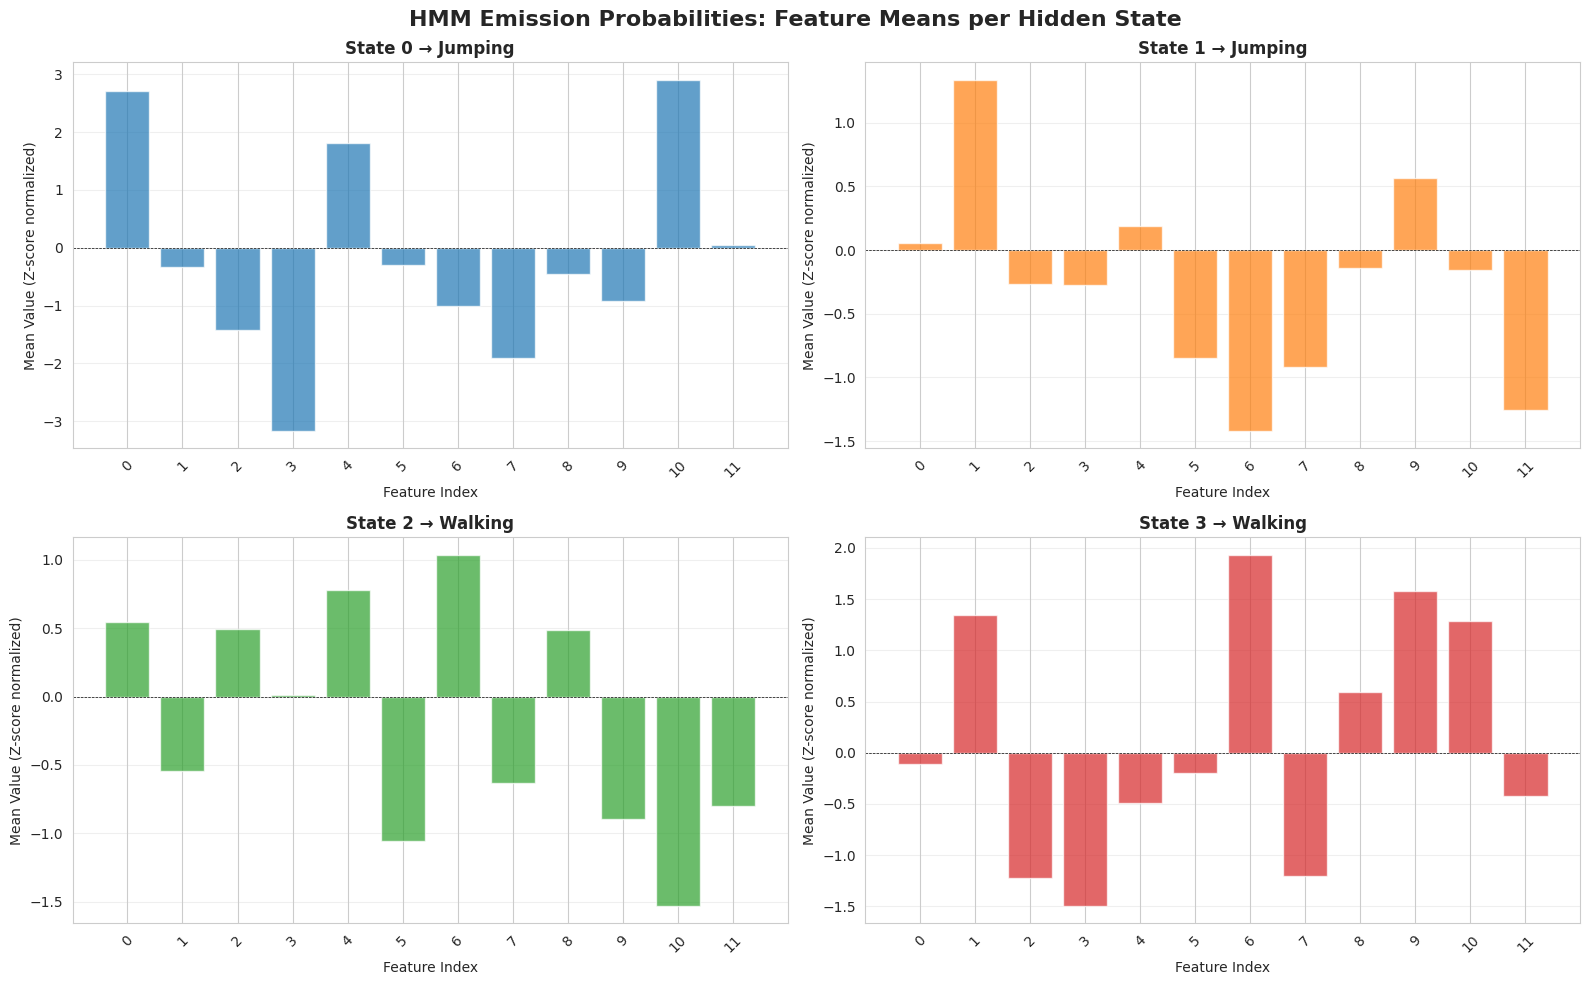

Saved HMM emission probabilities plot to: ../results/hmm_emission_probabilities.png

Feature Variances per State (first 6 features):

State 0 (jumping):
  Variances: [[ 3.72278235  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0. 

In [51]:
# ============================================
# Emission Probabilities Visualization
# ============================================

print("="*60)
print("EMISSION PROBABILITIES (GAUSSIAN MEANS)")
print("="*60)

# Show first 12 features for clarity
n_features_to_show = 12
feature_names_short = feature_cols[:n_features_to_show]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('HMM Emission Probabilities: Feature Means per Hidden State',
             fontsize=16, fontweight='bold')

for state in range(n_states):
    ax = axes[state // 2, state % 2]
    means = model.means_[state, :n_features_to_show]

    # Get mapped activity name
    mapped_label = state_mapping.get(state, state)
    activity_name = class_names[mapped_label]

    bars = ax.bar(range(n_features_to_show), means, color=f'C{state}', alpha=0.7)
    ax.set_title(f'State {state} → {activity_name.capitalize()}', fontweight='bold')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Mean Value (Z-score normalized)')
    ax.set_xticks(range(n_features_to_show))
    ax.set_xticklabels(range(n_features_to_show), rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()

# Save emission probabilities figure in external results folder
emission_plot_file = RESULTS_DIR / "hmm_emission_probabilities.png"
plt.savefig(emission_plot_file)
plt.show()

print(f"Saved HMM emission probabilities plot to: {emission_plot_file}")

# ============================================
# Feature variances per state (diagonal covariance)
# ============================================
print("\nFeature Variances per State (first 6 features):")
for state in range(n_states):
    mapped_label = state_mapping.get(state, state)
    activity_name = class_names[mapped_label]
    variances = model.covars_[state, :6]
    print(f"\nState {state} ({activity_name}):")
    print(f"  Variances: {variances}")


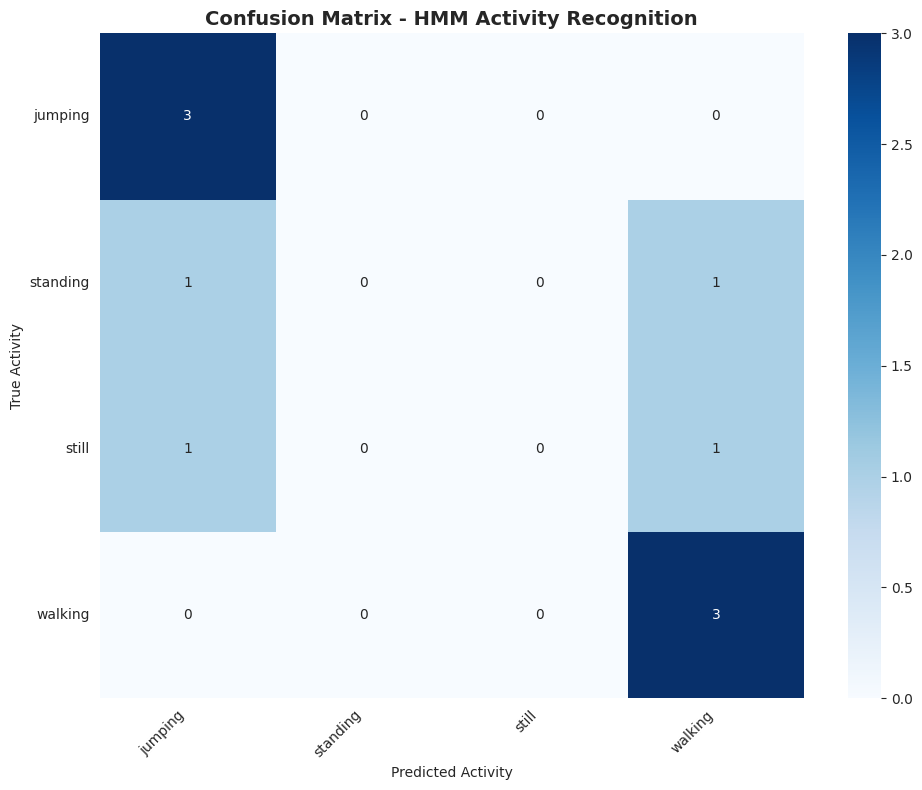

Saved confusion matrix to: ../results/confusion_matrix_seaborn.png

Classification Report:
              precision    recall  f1-score   support

     jumping       0.60      1.00      0.75         3
    standing       0.00      0.00      0.00         2
       still       0.00      0.00      0.00         2
     walking       0.60      1.00      0.75         3

    accuracy                           0.60        10
   macro avg       0.30      0.50      0.38        10
weighted avg       0.36      0.60      0.45        10

Saved classification report to: ../results/classification_report.txt


In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------
# Define RESULTS_DIR (external folder from another notebook)
# Adjust the path to where the 'results' folder actually is
RESULTS_DIR = Path("../results")  # <-- change this to your folder path
RESULTS_DIR.mkdir(parents=True, exist_ok=True)  # Ensure folder exists

# -------------------------------
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# -------------------------------
# Seaborn confusion matrix plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - HMM Activity Recognition', fontsize=14, fontweight='bold')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save Seaborn confusion matrix plot
cm_plot_file = RESULTS_DIR / "confusion_matrix_seaborn.png"
plt.savefig(cm_plot_file)
plt.show()

print(f"Saved confusion matrix to: {cm_plot_file}")

# -------------------------------
# Classification report
report = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)

print("\nClassification Report:")
print("="*60)
print(report)

# Save classification report to a text file
report_file = RESULTS_DIR / "classification_report.txt"
with open(report_file, "w") as f:
    f.write(report)

print(f"Saved classification report to: {report_file}")

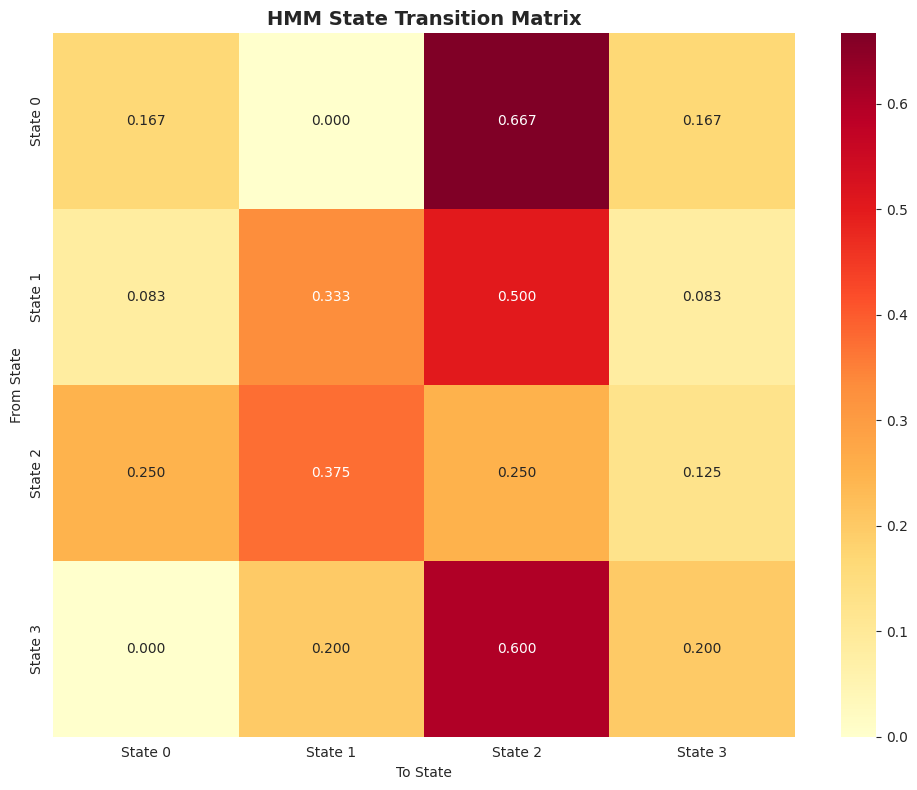

Saved HMM transition matrix plot to: ../results/hmm_transition_matrix.png


In [53]:
# Visualize transition matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    model.transmat_,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    xticklabels=[f'State {i}' for i in range(n_states)],
    yticklabels=[f'State {i}' for i in range(n_states)]
)
plt.title('HMM State Transition Matrix', fontsize=14, fontweight='bold')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()

# Save the transition matrix plot in external results folder
transmat_plot_file = RESULTS_DIR / "hmm_transition_matrix.png"
plt.savefig(transmat_plot_file)
plt.show()

print(f"Saved HMM transition matrix plot to: {transmat_plot_file}")


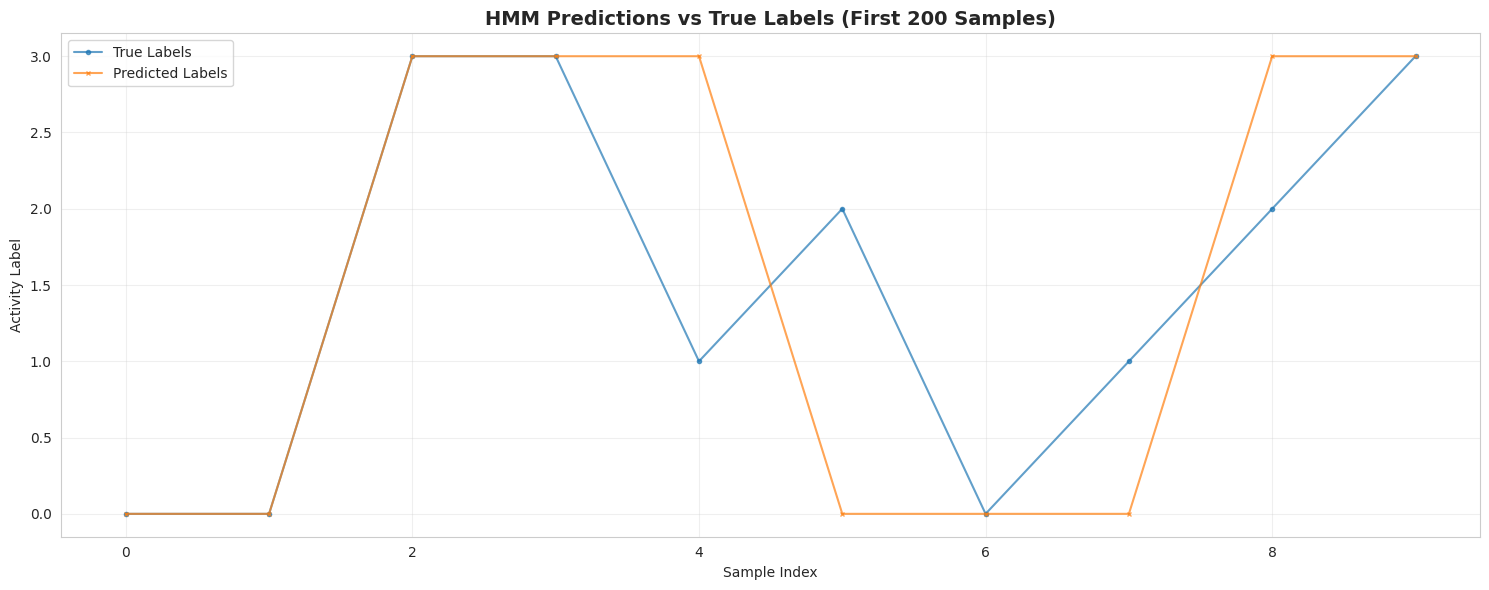

<Figure size 1200x600 with 0 Axes>

Saved decoded vs true labels plot to: ../results/decoded_vs_true_labels.png


In [54]:
# Plot decoded sequence vs true labels (first 200 samples)
n_samples_to_plot = 200

plt.figure(figsize=(15, 6))
plt.plot(y_test[:n_samples_to_plot], label='True Labels', marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred[:n_samples_to_plot], label='Predicted Labels', marker='x', markersize=3, alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Activity Label')
plt.title('HMM Predictions vs True Labels (First 200 Samples)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Save plot to results directory
decoded_plot_file = RESULTS_DIR / "decoded_vs_true_labels.png"
plt.savefig(decoded_plot_file)
plt.show()

print(f"Saved decoded vs true labels plot to: {decoded_plot_file}")

In [55]:
# Save metrics to CSV for report
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy, precision, recall, f1]
})

metrics_df.to_csv('hmm_metrics.csv', index=False)
print("✓ Metrics saved to 'hmm_metrics.csv'")
print(metrics_df)

✓ Metrics saved to 'hmm_metrics.csv'
      Metric  Value
0   Accuracy   0.60
1  Precision   0.36
2     Recall   0.60
3   F1-Score   0.45
